# Buổi 10 — Notebook 3: Máy Vector Hỗ trợ (SVM)

**Mục tiêu:**
- Hiểu khái niệm **siêu phẳng tách tối ưu** và **support vectors**
- Huấn luyện và đánh giá SVM tuyến tính
- Khám phá ảnh hưởng của tham số **C** (regularization)
- So sánh kernel tuyến tính và RBF

**Dữ liệu:** Breast Cancer (sklearn) — chiếu xuống 2D bằng PCA để minh họa.

**Ước tính thời gian:** ~30 phút


In [1]:
%load_ext autoreload
%autoreload 2

import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 110

from sklearn.datasets import load_breast_cancer
from sklearn.decomposition import PCA
from src import preprocessing, svm_utils


## 1. Dữ liệu và chiếu 2D

Ta dùng PCA chiếu 30 đặc trưng xuống 2 chiều để có thể **vẽ đường biên**.


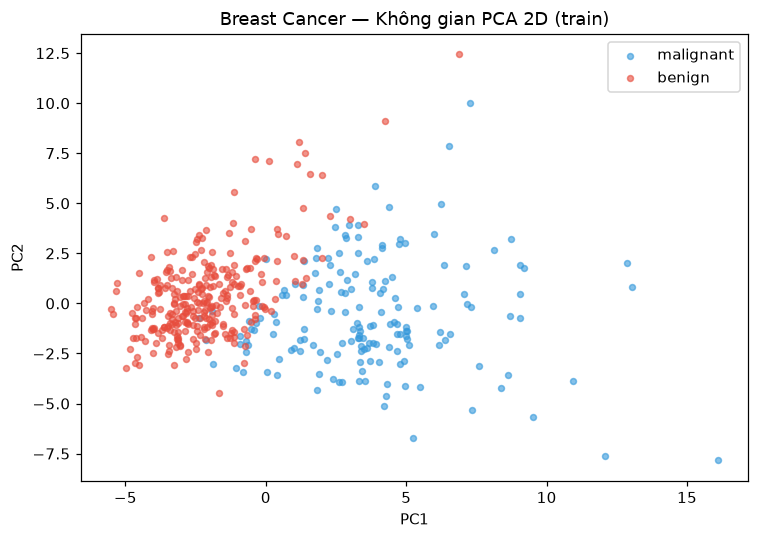

In [2]:
data = load_breast_cancer()
X, y = data.data, data.target
TEN_LOP = list(data.target_names)

X_train, X_test, y_train, y_test = preprocessing.chia_train_test(X, y)
_, X_tr_sc, X_te_sc = preprocessing.chuan_hoa(X_train, X_test)

# Chiếu xuống 2D (để vẽ đường biên)
pca = PCA(n_components=2, random_state=42)
X_tr_2d = pca.fit_transform(X_tr_sc)
X_te_2d = pca.transform(X_te_sc)

plt.figure(figsize=(7, 5))
for k, c in enumerate(['#3498db', '#e74c3c']):
    idx = y_train == k
    plt.scatter(X_tr_2d[idx, 0], X_tr_2d[idx, 1], c=c, s=15, alpha=0.6,
                label=TEN_LOP[k])
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Breast Cancer — Không gian PCA 2D (train)')
plt.legend()
plt.tight_layout()
plt.show()


## 2. SVM Tuyến tính

**Hàm cần hoàn thiện:** `svm_utils.huan_luyen_svm()`

Ta huấn luyện trên **dữ liệu 2D** (sau PCA) để sau đó có thể vẽ đường biên.


In [3]:
model_svm = svm_utils.huan_luyen_svm(X_tr_2d, y_train, C=1.0, kernel='linear')
print('Model:', model_svm)


Model: SVC(kernel='linear', random_state=42)


### 2.1 Support Vectors

**Hàm cần hoàn thiện:** `svm_utils.thong_tin_support_vectors()`


In [4]:
sv_info = svm_utils.thong_tin_support_vectors(model_svm)
print(f"Tổng số support vectors : {sv_info['so_luong']}")
print(f"Mỗi lớp                 : {sv_info['moi_lop']}")


Tổng số support vectors : 68
Mỗi lớp                 : [np.int32(34), np.int32(34)]


### 2.2 Vẽ đường biên quyết định

**Hàm cần hoàn thiện:** `svm_utils.ve_bien_quyet_dinh()`

Gợi ý: Tạo meshgrid → dự đoán → `plt.contourf` → vẽ điểm → đánh dấu support vectors.


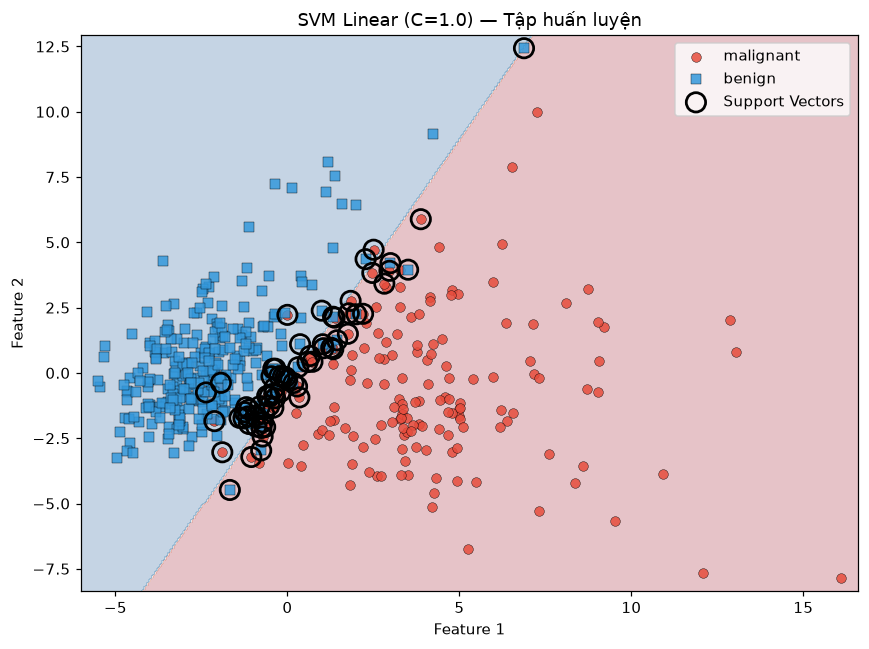

In [5]:
svm_utils.ve_bien_quyet_dinh(
    model_svm, X_tr_2d, y_train,
    ten_lop=TEN_LOP,
    tieu_de='SVM Linear (C=1.0) — Tập huấn luyện'
)


## 3. Ảnh hưởng của tham số C

C kiểm soát sự đánh đổi giữa **margin rộng** và **số lỗi phân loại**:
- **C nhỏ:** ưu tiên margin rộng, chấp nhận nhiều điểm bị phân loại sai  
- **C lớn:** ưu tiên phân loại đúng, margin hẹp hơn

**Nhiệm vụ:** Hoàn thiện đoạn code bên dưới để huấn luyện SVM với nhiều giá trị C
và quan sát sự thay đổi về accuracy và số support vectors.


In [6]:
# TODO: Hoàn thiện vòng lặp bên dưới
gia_tri_C = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]

ket_qua = []
for C in gia_tri_C:
    # 1. Huấn luyện SVM với C hiện tại
    # model = ...
    # 2. Tính accuracy trên tập test
    # acc = ...
    # 3. Lấy số support vectors
    # n_sv = ...
    # ket_qua.append({'C': C, 'acc': acc, 'n_sv': n_sv})
    pass  # Xóa dòng này khi hoàn thiện

# Sau khi hoàn thiện, bỏ comment phần vẽ biểu đồ bên dưới
# import pandas as pd
# df_c = pd.DataFrame(ket_qua)
# fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# axes[0].semilogx(df_c.C, df_c.acc, 'o-')
# axes[0].set_xlabel('C');  axes[0].set_ylabel('Accuracy (test)')
# axes[0].set_title('Accuracy vs C')
# axes[1].semilogx(df_c.C, df_c.n_sv, 's-', color='orange')
# axes[1].set_xlabel('C');  axes[1].set_ylabel('Số support vectors')
# axes[1].set_title('Support Vectors vs C')
# plt.tight_layout(); plt.show()


> **Câu hỏi 3.1:** Khi C → ∞, mô hình trở thành loại SVM nào (hard-margin hay soft-margin)?
> Điều này có thể gây ra vấn đề gì với dữ liệu không tuyến tính phân tách hoàn toàn?


## 4. SVM trên dữ liệu đầy đủ (30 đặc trưng)

Hãy huấn luyện SVM trên **toàn bộ 30 đặc trưng** (không qua PCA) để đạt độ chính xác cao hơn.

**Hàm cần hoàn thiện:** `svm_utils.danh_gia_svm()`


Độ chính xác: 0.9561

              precision    recall  f1-score   support

   malignant       0.93      0.95      0.94        43
      benign       0.97      0.96      0.96        71

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



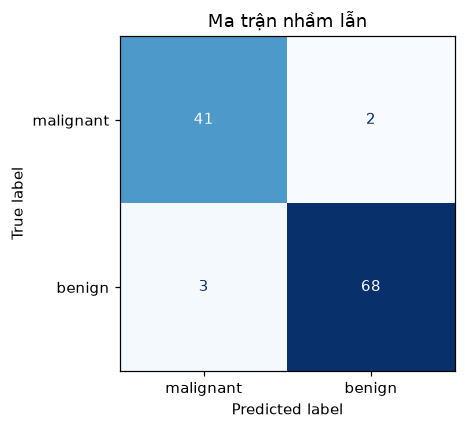

In [7]:
model_full = svm_utils.huan_luyen_svm(X_tr_sc, y_train, C=1.0, kernel='linear')
ket_qua_full = svm_utils.danh_gia_svm(model_full, X_te_sc, y_test, ten_lop=TEN_LOP)


## 5. (Nâng cao) Kernel RBF

Kernel RBF chiếu dữ liệu lên không gian chiều cao hơn, cho phép tạo đường biên **phi tuyến**.

So sánh SVM tuyến tính vs RBF trên tập test.


Độ chính xác: 0.9825

              precision    recall  f1-score   support

   malignant       1.00      0.95      0.98        43
      benign       0.97      1.00      0.99        71

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



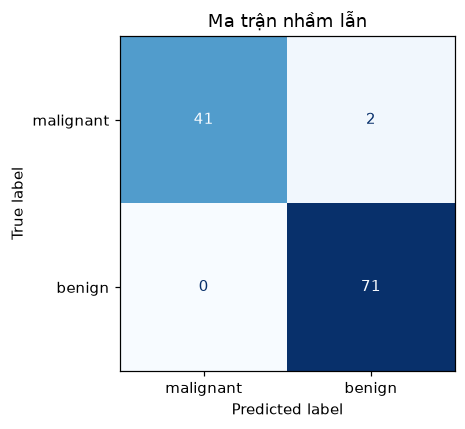

--- So sánh ---
SVM Linear (30D): 0.9561
SVM RBF    (30D): 0.9825


In [8]:
model_rbf = svm_utils.huan_luyen_svm(X_tr_sc, y_train, C=1.0, kernel='rbf')
ket_qua_rbf = svm_utils.danh_gia_svm(model_rbf, X_te_sc, y_test, ten_lop=TEN_LOP)

from sklearn.metrics import accuracy_score
print('--- So sánh ---')
print(f'SVM Linear (30D): {ket_qua_full["accuracy"]:.4f}')
print(f'SVM RBF    (30D): {ket_qua_rbf["accuracy"]:.4f}')


## Câu hỏi tổng kết

1. Tại sao SVM cần **chuẩn hóa đặc trưng** trước khi huấn luyện?
2. Support vectors là gì? Nếu ta xóa bỏ các điểm **không phải** support vectors,
   mô hình SVM có thay đổi không?
3. So với Logistic Regression (notebook 2), SVM có ưu/nhược điểm gì?
4. *(Thách thức)* Cài đặt lại SVM tuyến tính từ đầu bằng gradient descent
   dùng **Hinge Loss**: L(w) = max(0, 1 − y·(wᵀx + b))

---
**Chúc mừng! Bạn đã hoàn thành Buổi 10.** 🎉
